## 1. Setup & Imports

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from sklearn.utils import resample

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGSIZE = (10, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Data



In [49]:

results      = pd.read_csv('results.csv')
qualifying   = pd.read_csv('qualifying.csv')
races        = pd.read_csv('races.csv')
drivers      = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
circuits     = pd.read_csv('circuits.csv')

print('Shapes:')
for name, df in [('results', results), ('qualifying', qualifying), ('races', races),
                 ('drivers', drivers), ('constructors', constructors), ('circuits', circuits)]:
    print(f'  {name:15s}: {df.shape}')

Shapes:
  results        : (26759, 18)
  qualifying     : (10494, 9)
  races          : (1125, 18)
  drivers        : (861, 9)
  constructors   : (212, 5)
  circuits       : (77, 9)


## 3. Merge & Build Master DataFrame

In [50]:

for df in [results, qualifying, races, drivers, constructors, circuits]:
    df.replace('\\N', np.nan, inplace=True)


df = results.merge(races[['raceId','year','circuitId','name']], on='raceId', how='left')
df.rename(columns={'name': 'race_name'}, inplace=True)


drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
df = df.merge(drivers[['driverId','driver_name','nationality']], on='driverId', how='left')


df = df.merge(constructors[['constructorId','name','nationality']],
              on='constructorId', how='left', suffixes=('_driver','_constructor'))
df.rename(columns={'name': 'constructor_name'}, inplace=True)


df = df.merge(circuits[['circuitId','country']], on='circuitId', how='left')


qual_cols = qualifying[['raceId','driverId','position']].copy()
qual_cols.rename(columns={'position': 'quali_position'}, inplace=True)
df = df.merge(qual_cols, on=['raceId','driverId'], how='left')

print(f'Master dataframe shape: {df.shape}')
df.head(3)

Master dataframe shape: (26759, 27)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,statusId,year,circuitId,race_name,driver_name,nationality_driver,constructor_name,nationality_constructor,country,quali_position
0,1,18,1,1,22,1,1,1,1,10.0,...,1,2008,1,Australian Grand Prix,Lewis Hamilton,British,McLaren,British,Australia,1.0
1,2,18,2,2,3,5,2,2,2,8.0,...,1,2008,1,Australian Grand Prix,Nick Heidfeld,German,BMW Sauber,German,Australia,5.0
2,3,18,3,3,7,7,3,3,3,6.0,...,1,2008,1,Australian Grand Prix,Nico Rosberg,German,Williams,British,Australia,7.0


## 4. Feature Engineering & Target Variable

In [51]:

numeric_cols = ['positionOrder','grid','laps','milliseconds','fastestLapSpeed','quali_position','year']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


# positionOrder is the actual finishing position (1=winner, always filled)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

print(f'Podium class distribution:')
print(df['podium'].value_counts())
print(f'\nPodium rate: {df["podium"].mean():.1%}')

Podium class distribution:
podium
0    23362
1     3397
Name: count, dtype: int64

Podium rate: 12.7%


In [52]:

df = df[df['year'] >= 2000].copy()
print(f'Rows after filtering to 2000+: {len(df)}')


top_constructors = ['Mercedes', 'Ferrari', 'Red Bull', 'McLaren', 'Williams', 'Renault']
df['is_top_constructor'] = df['constructor_name'].isin(top_constructors).astype(int)


df['grid_position'] = df['grid']  # rename for clarity


df['finished_race'] = (df['statusId'] == 1).astype(int)

print('Feature engineering complete!')

Rows after filtering to 2000+: 10079
Feature engineering complete!


## 5. Exploratory Data Analysis (EDA)

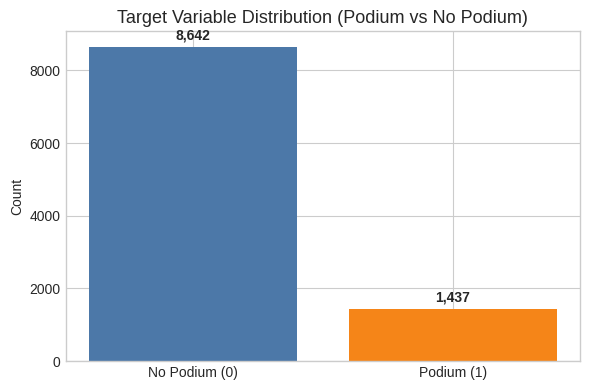

Note: Class imbalance is expected — only 3 podium spots per race!


In [53]:

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['podium'].value_counts()
bars = ax.bar(['No Podium (0)', 'Podium (1)'], counts.values, color=['#4C78A8','#F58518'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Target Variable Distribution (Podium vs No Podium)', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot_class_balance.png', dpi=150)
plt.show()
print('Note: Class imbalance is expected — only 3 podium spots per race!')

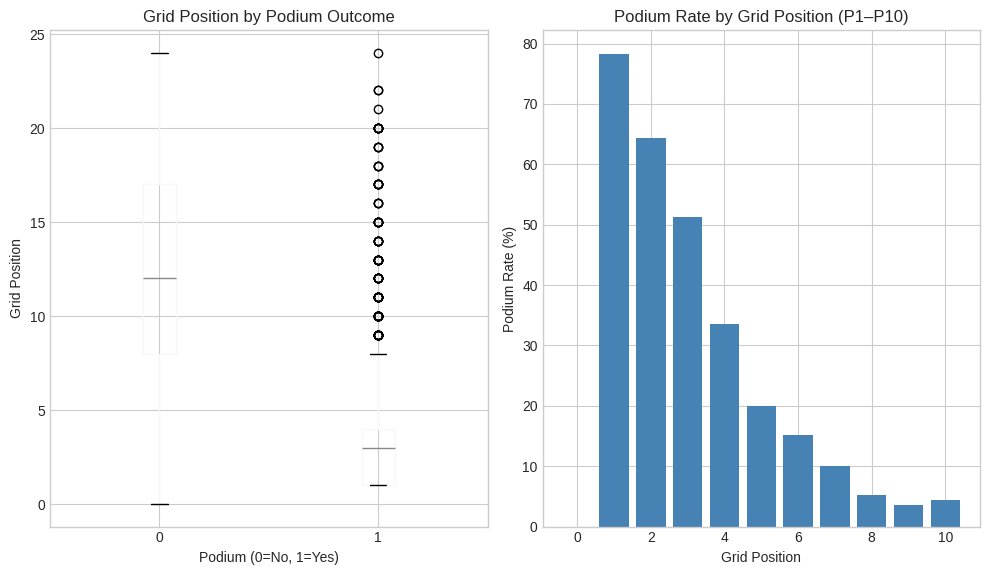

In [54]:

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)


df.boxplot(column='grid_position', by='podium', ax=axes[0])
axes[0].set_title('Grid Position by Podium Outcome')
axes[0].set_xlabel('Podium (0=No, 1=Yes)')
axes[0].set_ylabel('Grid Position')
plt.sca(axes[0])
plt.title('Grid Position by Podium Outcome')


grid_podium = df[df['grid_position'] <= 10].groupby('grid_position')['podium'].mean()
axes[1].bar(grid_podium.index, grid_podium.values * 100, color='steelblue')
axes[1].set_title('Podium Rate by Grid Position (P1–P10)')
axes[1].set_xlabel('Grid Position')
axes[1].set_ylabel('Podium Rate (%)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('plot_grid_vs_podium.png', dpi=150)
plt.show()

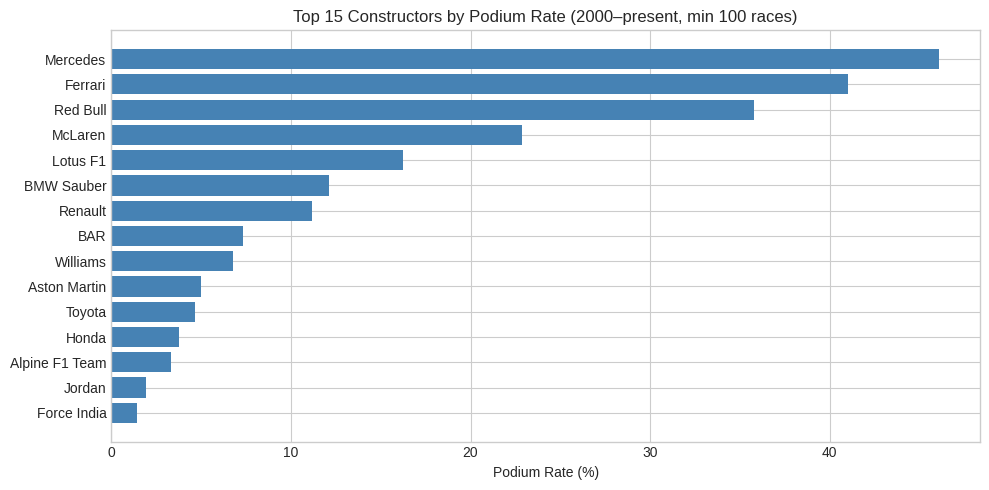

In [55]:

constructor_stats = (
    df.groupby('constructor_name')['podium']
    .agg(['sum','count'])
    .assign(podium_rate=lambda x: x['sum'] / x['count'])
    .query('count >= 100')  # only constructors with 100+ entries
    .sort_values('podium_rate', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(constructor_stats.index, constructor_stats['podium_rate'] * 100, color='steelblue')
ax.set_xlabel('Podium Rate (%)')
ax.set_title('Top 15 Constructors by Podium Rate (2000–present, min 100 races)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plot_constructor_podium_rate.png', dpi=150)
plt.show()

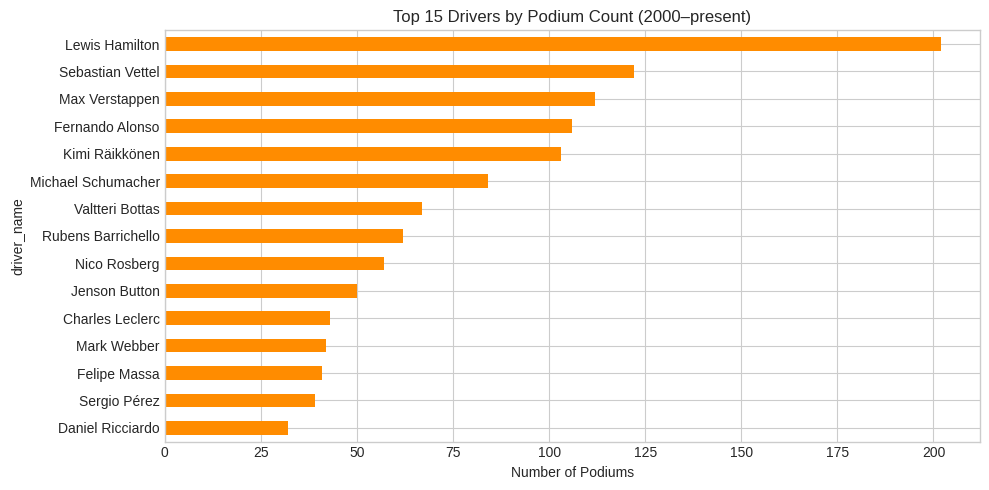

In [56]:

driver_podiums = (
    df[df['podium'] == 1]
    .groupby('driver_name')['podium']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
driver_podiums.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Number of Podiums')
ax.set_title('Top 15 Drivers by Podium Count (2000–present)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plot_top_drivers.png', dpi=150)
plt.show()

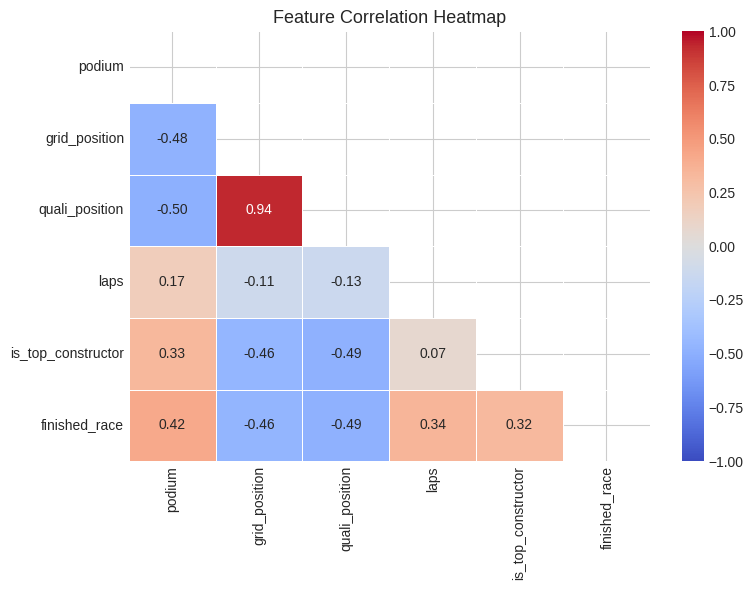

In [57]:

corr_cols = ['podium','grid_position','quali_position','laps','is_top_constructor','finished_race']
corr_data = df[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150)
plt.show()

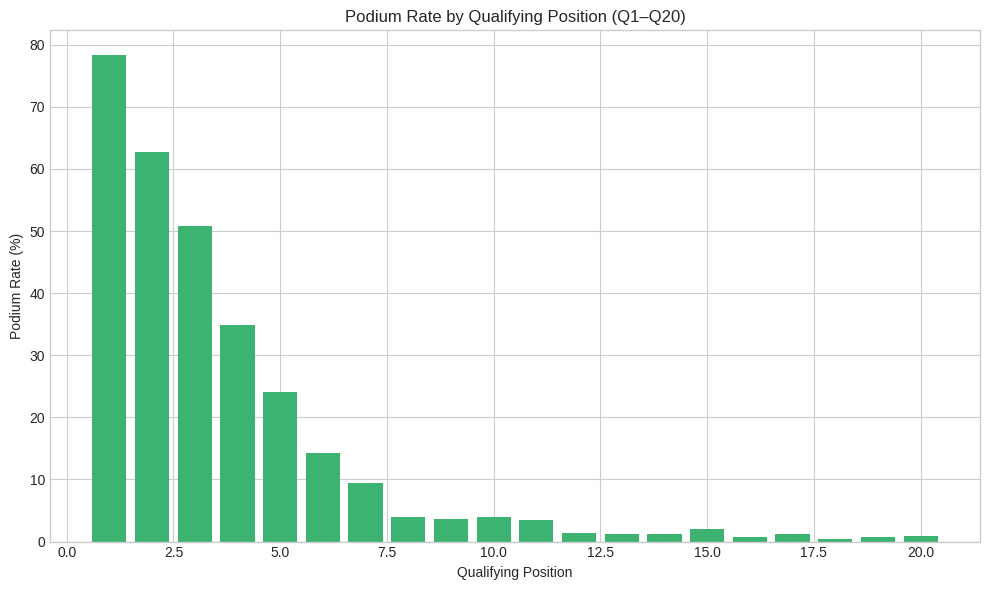

In [58]:

qual_podium = (
    df[df['quali_position'].between(1, 20)]
    .groupby('quali_position')['podium']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(qual_podium.index, qual_podium.values, color='mediumseagreen')
ax.set_xlabel('Qualifying Position')
ax.set_ylabel('Podium Rate (%)')
ax.set_title('Podium Rate by Qualifying Position (Q1–Q20)', fontsize=12)
plt.tight_layout()
plt.savefig('plot_quali_vs_podium.png', dpi=150)
plt.show()

## 6. Preprocessing

In [59]:

FEATURES = [
    'grid_position',
    'quali_position',
    'laps',
    'is_top_constructor',
    'finished_race',
    'constructor_name',
    'nationality_driver',
    'year'
]
TARGET = 'podium'


model_df = df[FEATURES + [TARGET]].dropna(subset=['grid_position','quali_position','laps'])
print(f'Modelling dataset shape: {model_df.shape}')


le = LabelEncoder()
for col in ['constructor_name','nationality_driver']:
    model_df[col] = le.fit_transform(model_df[col].astype(str))


X = model_df[FEATURES]
y = model_df[TARGET]

print(f'\nClass balance in modelling set:')
print(y.value_counts())
print(f'Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.1f}:1')

Modelling dataset shape: (9098, 9)

Class balance in modelling set:
podium
0    7793
1    1305
Name: count, dtype: int64
Imbalance ratio: 6.0:1


In [60]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

print('Using class_weight="balanced" in all models to handle imbalance.')

Train size: 7278  |  Test size: 1820
Using class_weight="balanced" in all models to handle imbalance.


## 7. Model Training

In [61]:

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:,1]
print('Logistic Regression trained!')

Logistic Regression trained!


In [62]:

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]
print('Random Forest trained!')

Random Forest trained!


In [63]:

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42
)
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:,1]
print('Gradient Boosting trained!')

Gradient Boosting trained!


## 8. Evaluation

In [64]:

def get_metrics(y_true, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4)
    }

metrics = pd.DataFrame([
    get_metrics(y_test, lr_pred, lr_proba, 'Logistic Regression'),
    get_metrics(y_test, rf_pred, rf_proba, 'Random Forest'),
    get_metrics(y_test, gb_pred, gb_proba, 'Gradient Boosting')
])

print('=== Model Comparison ===' )
print(metrics.to_string(index=False))

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8445     0.4781  0.9195    0.6291   0.9437
      Random Forest    0.8989     0.6097  0.8199    0.6993   0.9473
  Gradient Boosting    0.9082     0.7043  0.6207    0.6599   0.9469


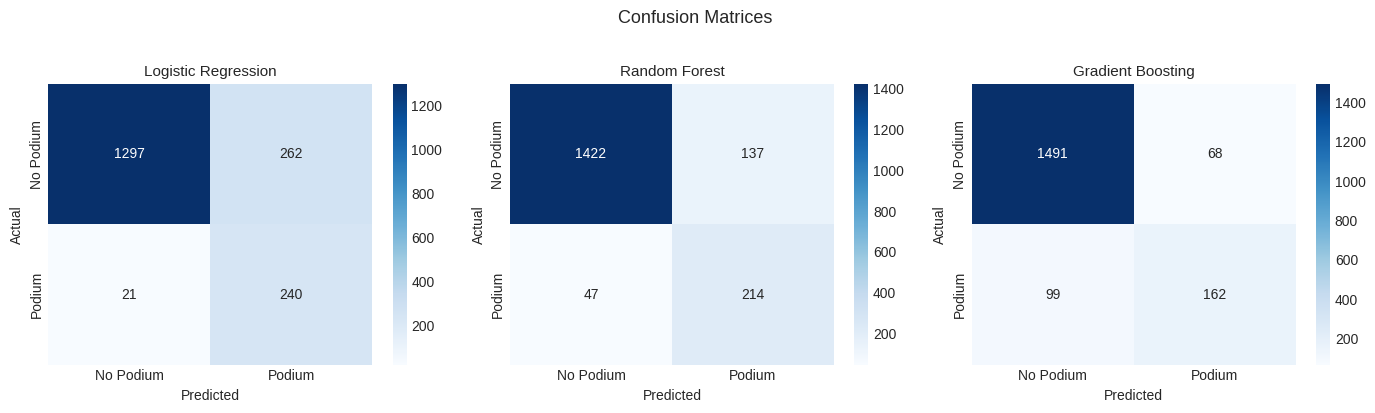

In [65]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models_data = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred)
]

for ax, (name, pred) in zip(axes, models_data):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Podium','Podium'],
                yticklabels=['No Podium','Podium'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

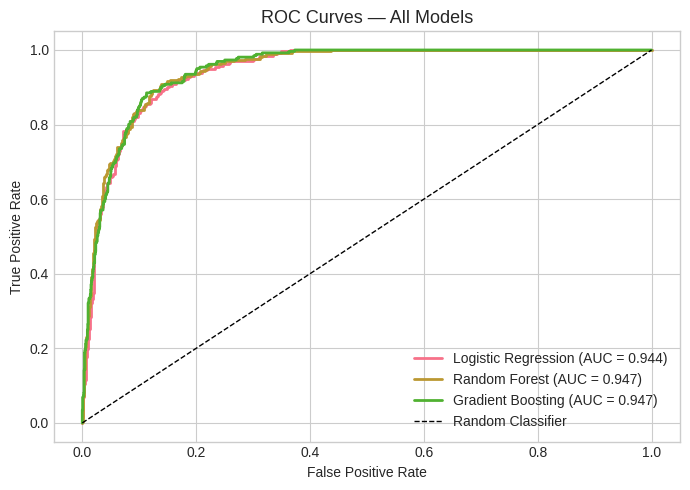

In [66]:

fig, ax = plt.subplots(figsize=(7, 5))

for name, proba in [
    ('Logistic Regression', lr_proba),
    ('Random Forest',       rf_proba),
    ('Gradient Boosting',   gb_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150)
plt.show()

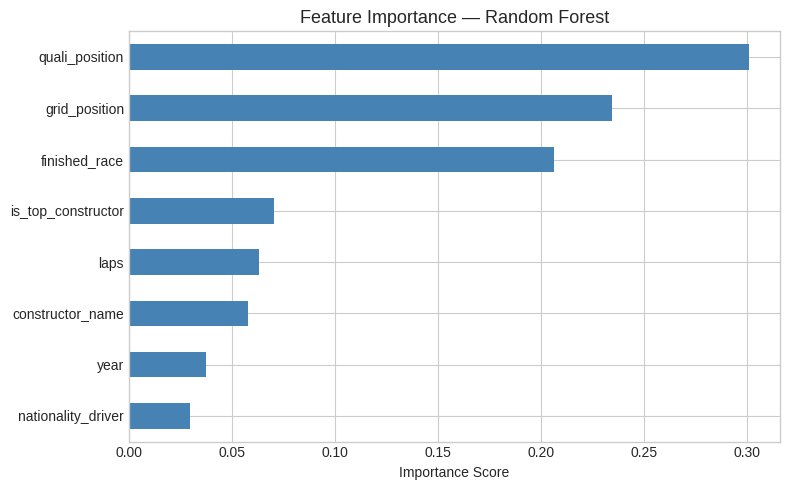

Top feature: quali_position


In [67]:

feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()
print('Top feature:', feat_imp.idxmax())

In [68]:

print('5-Fold Cross-Validation ROC-AUC Scores\n')
for name, model, X_cv, y_cv in [
    ('Logistic Regression', lr, X_train_scaled, y_train),
    ('Random Forest',       rf, X_train,        y_train),
    ('Gradient Boosting',   gb, X_train,        y_train)
]:
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='roc_auc', n_jobs=-1)
    print(f'{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

5-Fold Cross-Validation ROC-AUC Scores

Logistic Regression      : 0.9510 ± 0.0023
Random Forest            : 0.9558 ± 0.0030
Gradient Boosting        : 0.9573 ± 0.0036
